In [8]:
import gzip
import sys
from pathlib import Path

import warnings
import itertools

import numpy as np
import pandas as pd

import scipy
from scipy import stats


import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns

from IPython.display import display
warnings.filterwarnings("ignore")

import korflab

In [9]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 5.0,
    "dpi": 300,
}


def set_plot_style(
    *,
    # Fonts
    base_fontsize=11,
    title_fontsize=14,
    label_fontsize=13,
    tick_fontsize=11,
    legend_fontsize=11,

    dpi=300,

    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,

    tick_size_major=6,
    tick_dir="out",

    grid=False,

    fig_w=6.0,
    fig_h=5.0,
):

    sns.set_style("ticks")

    mpl.rcParams.update({

        # =====================================
        # Fonts
        # =====================================
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        # =====================================
        # Figure
        # =====================================
        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        # =====================================
        # Axes
        # =====================================
        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        # =====================================
        # Ticks
        # =====================================
        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        # =====================================
        # Legend
        # =====================================
        "legend.frameon": False,

        # =====================================
        # Save figure
        # =====================================
        "savefig.bbox": "tight",
        "savefig.transparent": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(
    w=None,
    h=None,
    dpi=None,
):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


set_plot_style()

In [10]:
# ============================================
# Input FASTQ files
# ============================================

fastq_dir = Path("/mnt/h/1k_fastq")

fastq_files = sorted(fastq_dir.glob("*_1k.fastq.gz"))

for f in fastq_files:
    print(f.name)

CR.log.P_1k.fastq.gz
CR.log.T_1k.fastq.gz
CR.stat.P_1k.fastq.gz
CR.stat.T_1k.fastq.gz
sample1_1k.fastq.gz
sample3_1k.fastq.gz
sample5_1k.fastq.gz
sample6_1k.fastq.gz


In [11]:
# ============================================
# Sample metadata
# ============================================

records = []

for f in fastq_files:
    name = f.name.replace("_1k.fastq.gz", "")

    if name.startswith("sample"):
        dataset = "New"
    else:
        dataset = "Old"

    records.append({
        "Sample": name,
        "Dataset": dataset,
        "Path": f,
    })

sample_meta = pd.DataFrame(records)

display(sample_meta)

,Sample,Dataset,Path
0,CR.log.P,Old,/mnt/h/1k_fastq/CR.log.P_1k.fastq.gz
1,CR.log.T,Old,/mnt/h/1k_fastq/CR.log.T_1k.fastq.gz
2,CR.stat.P,Old,/mnt/h/1k_fastq/CR.stat.P_1k.fastq.gz
3,CR.stat.T,Old,/mnt/h/1k_fastq/CR.stat.T_1k.fastq.gz
4,sample1,New,/mnt/h/1k_fastq/sample1_1k.fastq.gz
5,sample3,New,/mnt/h/1k_fastq/sample3_1k.fastq.gz
6,sample5,New,/mnt/h/1k_fastq/sample5_1k.fastq.gz
7,sample6,New,/mnt/h/1k_fastq/sample6_1k.fastq.gz


In [46]:
# ============================================
# Read one FASTQ
# ============================================

def summarize_fastq(path, sample, dataset):

    records = []

    for header, seq, plus, qual in korflab.readfastq(str(path)):

        length = len(seq)

        q = np.fromiter(
            (ord(c) - 33 for c in qual),
            dtype=float,
        )

        mean_q = q.mean()
        median_q = np.median(q)
        sd_q = q.std()
        cv_q = (
            sd_q
            / mean_q
            * 100
        )

        min_q = q.min()
        max_q = q.max()

        gc = (
            (seq.count("G") + seq.count("C"))
            / length
            * 100
        )

        n_pct = (
            seq.count("N")
            / length
            * 100
        )

        records.append({
            "Dataset": dataset,
            "Sample": sample,
            "Read_ID": header,

            "Length": length,

            "Mean_Q": mean_q,
            "Median_Q": median_q,
            "Quality_SD": sd_q,
            "Quality_CV": cv_q,
            "Min_Q": min_q,
            "Max_Q": max_q,

            "GC": gc,
            "N_Pct": n_pct,
        })

    return pd.DataFrame(records)

In [47]:
# ============================================
# Build read-level QC table
# ============================================

dfs = []

for _, row in sample_meta.iterrows():
    print(f"Reading {row['Sample']}...")

    df = summarize_fastq(
        path=row["Path"],
        sample=row["Sample"],
        dataset=row["Dataset"],
    )

    dfs.append(df)

read_qc = pd.concat(dfs, ignore_index=True)

display(read_qc.head())
print(read_qc.shape)

Reading CR.log.P...
Reading CR.log.T...
Reading CR.stat.P...
Reading CR.stat.T...
Reading sample1...
Reading sample3...
Reading sample5...
Reading sample6...


,Dataset,Sample,Read_ID,Length,Mean_Q,Median_Q,Quality_SD,Quality_CV,Min_Q,Max_Q,GC,N_Pct
0,Old,CR.log.P,a80c0e32-92f8-433e-8233-aae54848510a runid=5eb...,384,30.541667,34.0,11.647529,38.136520,2.0,50.0,49.739583,0.0
1,Old,CR.log.P,153cf9cf-3e7c-476f-9ee0-4c3abafe3152 runid=5eb...,397,25.498741,28.0,11.230497,44.043338,1.0,50.0,49.622166,0.0
2,Old,CR.log.P,79b719e6-d39b-4110-8029-b558063d580d runid=5eb...,501,23.584830,25.0,11.926559,50.568771,2.0,50.0,54.291417,0.0
3,Old,CR.log.P,6313fbba-a976-4c00-9976-84157d83ee17 runid=5eb...,325,15.390769,13.0,11.466254,74.500854,1.0,50.0,50.461538,0.0
4,Old,CR.log.P,67a4f772-f5e9-46d6-b434-8255e085a871 runid=5eb...,544,33.810662,38.0,13.588997,40.191456,2.0,50.0,53.492647,0.0


(8000, 12)


In [48]:
# ============================================
# Inspect read-level QC table
# ============================================

display(read_qc.head())

print(read_qc.shape)

read_qc.info()

read_qc.describe()

,Dataset,Sample,Read_ID,Length,Mean_Q,Median_Q,Quality_SD,Quality_CV,Min_Q,Max_Q,GC,N_Pct
0,Old,CR.log.P,a80c0e32-92f8-433e-8233-aae54848510a runid=5eb...,384,30.541667,34.0,11.647529,38.136520,2.0,50.0,49.739583,0.0
1,Old,CR.log.P,153cf9cf-3e7c-476f-9ee0-4c3abafe3152 runid=5eb...,397,25.498741,28.0,11.230497,44.043338,1.0,50.0,49.622166,0.0
2,Old,CR.log.P,79b719e6-d39b-4110-8029-b558063d580d runid=5eb...,501,23.584830,25.0,11.926559,50.568771,2.0,50.0,54.291417,0.0
3,Old,CR.log.P,6313fbba-a976-4c00-9976-84157d83ee17 runid=5eb...,325,15.390769,13.0,11.466254,74.500854,1.0,50.0,50.461538,0.0
4,Old,CR.log.P,67a4f772-f5e9-46d6-b434-8255e085a871 runid=5eb...,544,33.810662,38.0,13.588997,40.191456,2.0,50.0,53.492647,0.0


(8000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Dataset     8000 non-null   object 
 1   Sample      8000 non-null   object 
 2   Read_ID     8000 non-null   object 
 3   Length      8000 non-null   int64  
 4   Mean_Q      8000 non-null   float64
 5   Median_Q    8000 non-null   float64
 6   Quality_SD  8000 non-null   float64
 7   Quality_CV  8000 non-null   float64
 8   Min_Q       8000 non-null   float64
 9   Max_Q       8000 non-null   float64
 10  GC          8000 non-null   float64
 11  N_Pct       8000 non-null   float64
dtypes: float64(8), int64(1), object(3)
memory usage: 750.1+ KB


,Length,Mean_Q,Median_Q,Quality_SD,Quality_CV,Min_Q,Max_Q,GC,N_Pct
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.0
mean,646.226875,26.072542,28.513687,12.806317,50.549865,1.489000,49.361125,52.673842,0.0
std,394.429700,4.766974,6.667329,1.279718,9.053971,0.523845,2.436587,4.718982,0.0
min,126.000000,10.677291,7.000000,4.879752,26.666269,1.000000,22.000000,22.932917,0.0
25%,377.000000,22.827232,24.000000,12.161230,43.675355,1.000000,50.000000,49.586348,0.0
50%,504.000000,26.401016,30.000000,12.889138,49.810246,1.000000,50.000000,52.641522,0.0
75%,793.250000,29.743892,34.000000,13.589532,56.454650,2.000000,50.000000,56.034797,0.0
max,5365.000000,37.090546,41.000000,17.415200,89.018180,4.000000,50.000000,65.492958,0.0


In [49]:
# ============================================
# Sample summary
# ============================================

summary = (
    read_qc
    .groupby(["Dataset", "Sample"])
    .agg(
        Reads=("Read_ID", "count"),

        Mean_Length=("Length", "mean"),
        Median_Length=("Length", "median"),
        Min_Length=("Length", "min"),
        Max_Length=("Length", "max"),

        Mean_Q=("Mean_Q", "mean"),
        Median_Q=("Median_Q", "mean"),

        Mean_Q_SD=("Quality_SD", "mean"),
        Mean_Q_CV=("Quality_CV", "mean"),

        Mean_GC=("GC", "mean"),
        Mean_N_Pct=("N_Pct", "mean"),
    )
    .reset_index()
)

display(summary.round(2))

,Dataset,Sample,Reads,Mean_Length,Median_Length,Min_Length,Max_Length,Mean_Q,Median_Q,Mean_Q_SD,Mean_Q_CV,Mean_GC,Mean_N_Pct
0,New,sample1,1000,897.38,844.0,237,3062,27.73,30.51,12.61,46.63,55.12,0.0
1,New,sample3,1000,882.18,791.0,239,5365,27.76,30.52,12.88,47.51,54.62,0.0
2,New,sample5,1000,817.38,691.0,205,3175,27.46,30.12,12.73,47.61,54.29,0.0
3,New,sample6,1000,732.55,620.0,129,3371,27.72,30.68,12.90,47.66,53.87,0.0
4,Old,CR.log.P,1000,497.41,443.0,126,3344,25.23,27.62,12.86,52.21,51.88,0.0
5,Old,CR.log.T,1000,428.46,386.0,209,3247,23.86,25.78,12.64,54.28,50.14,0.0
6,Old,CR.stat.P,1000,501.11,426.0,231,3143,24.78,26.84,12.79,52.93,51.21,0.0
7,Old,CR.stat.T,1000,413.34,375.5,175,2118,24.03,26.04,13.05,55.56,50.25,0.0


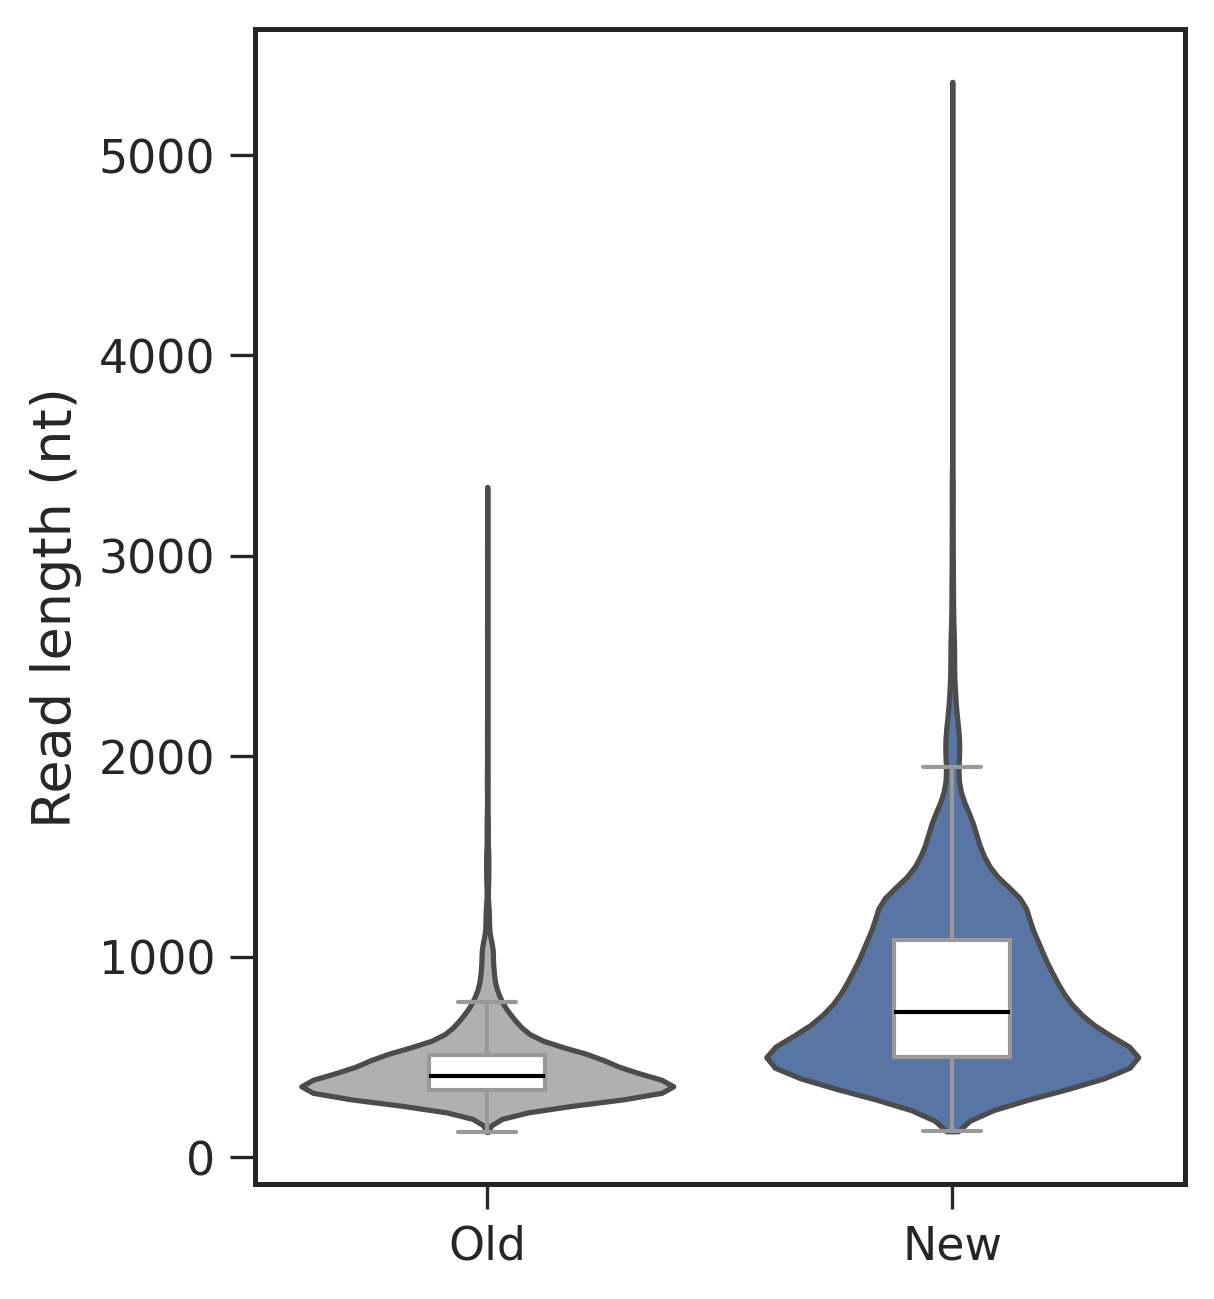

In [50]:
# ============================================
# Figure 1A
# Read length distribution
# Old vs New
# ============================================

dataset_palette = {
    "Old": "#B0B0B0",
    "New": "#4C72B0",
}

fig, ax = make_fig(
    w=4,
    h=5,
)

sns.violinplot(
    data=read_qc,
    x="Dataset",
    y="Length",
    palette=dataset_palette,
    inner=None,
    cut=0,
    legend=False,
    ax=ax,
)

sns.boxplot(
    data=read_qc,
    x="Dataset",
    y="Length",
    width=0.25,
    palette=["white", "white"],
    showcaps=True,
    showfliers=False,
    boxprops={"facecolor": "white", "zorder": 2},
    whiskerprops={"linewidth": 1},
    medianprops={"color": "black"},
    legend=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Read length (nt)")

plt.show()

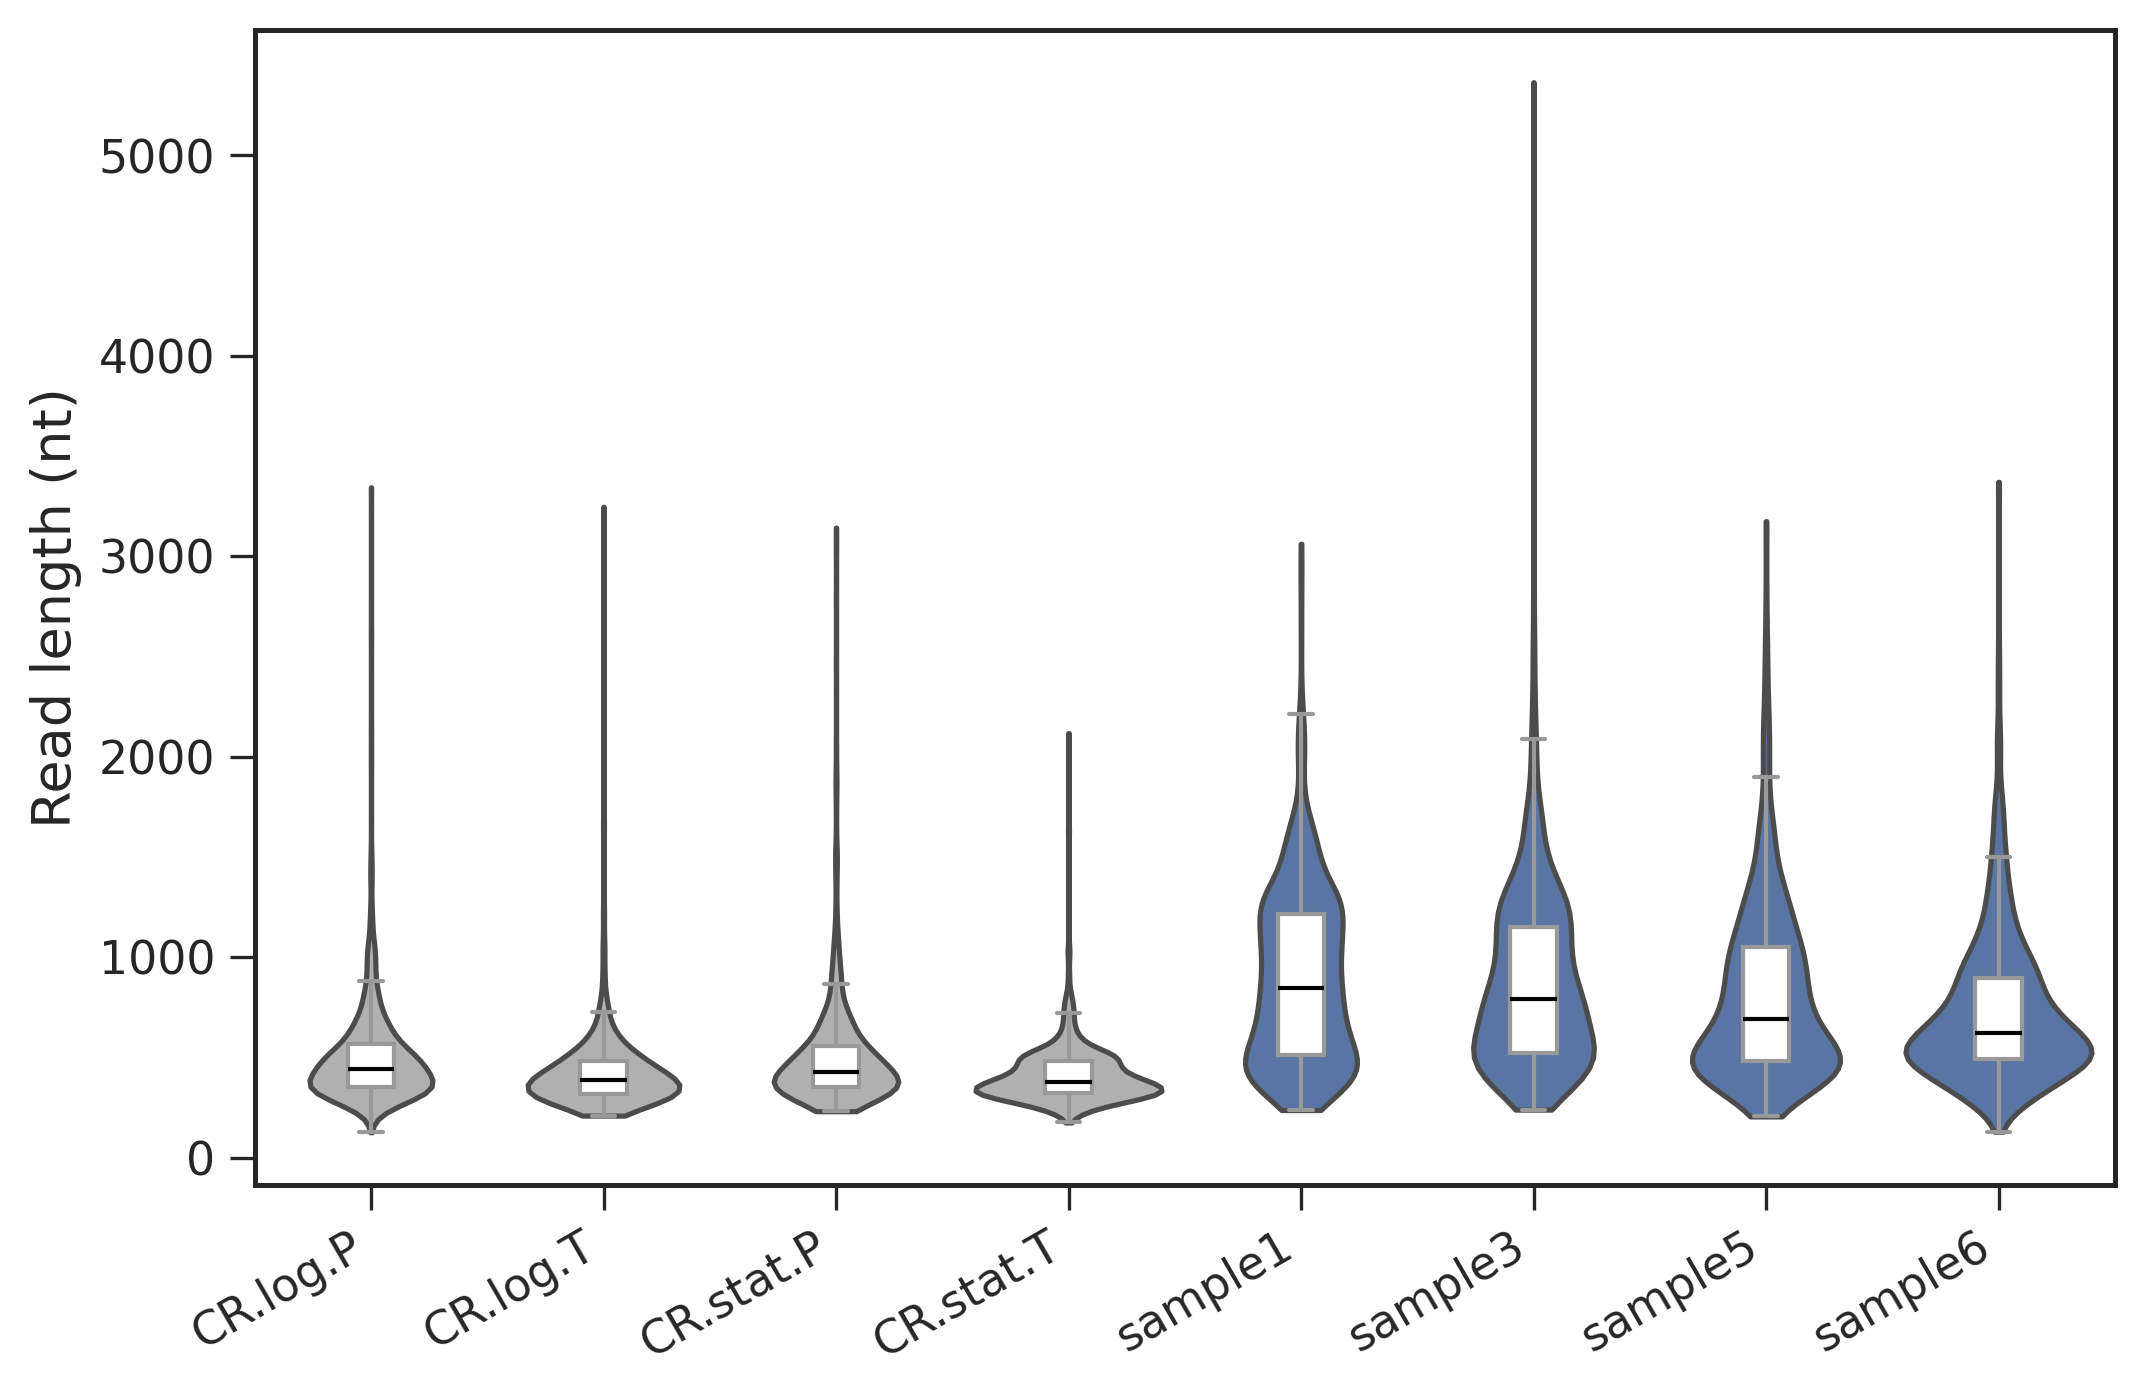

In [51]:
# ============================================
# Figure 1B
# Read length distribution
# Individual samples
# ============================================

sample_order = [
    "CR.log.P",
    "CR.log.T",
    "CR.stat.P",
    "CR.stat.T",
    "sample1",
    "sample3",
    "sample5",
    "sample6",
]

dataset_palette = {
    "Old": "#B0B0B0",
    "New": "#4C72B0",
}

fig, ax = make_fig(
    w=8,
    h=5,
)

sns.violinplot(
    data=read_qc,
    x="Sample",
    y="Length",
    hue="Dataset",
    order=sample_order,
    palette=dataset_palette,
    inner=None,
    cut=0,
    dodge=False,
    legend=False,
    ax=ax,
)

sns.boxplot(
    data=read_qc,
    x="Sample",
    y="Length",
    hue="Dataset",
    order=sample_order,
    palette=["white", "white"],
    dodge=False,
    width=0.20,
    showcaps=True,
    showfliers=False,
    boxprops={"facecolor": "white", "zorder": 2},
    whiskerprops={"linewidth": 1},
    medianprops={"color": "black"},
    legend=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Read length (nt)")

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

plt.show()

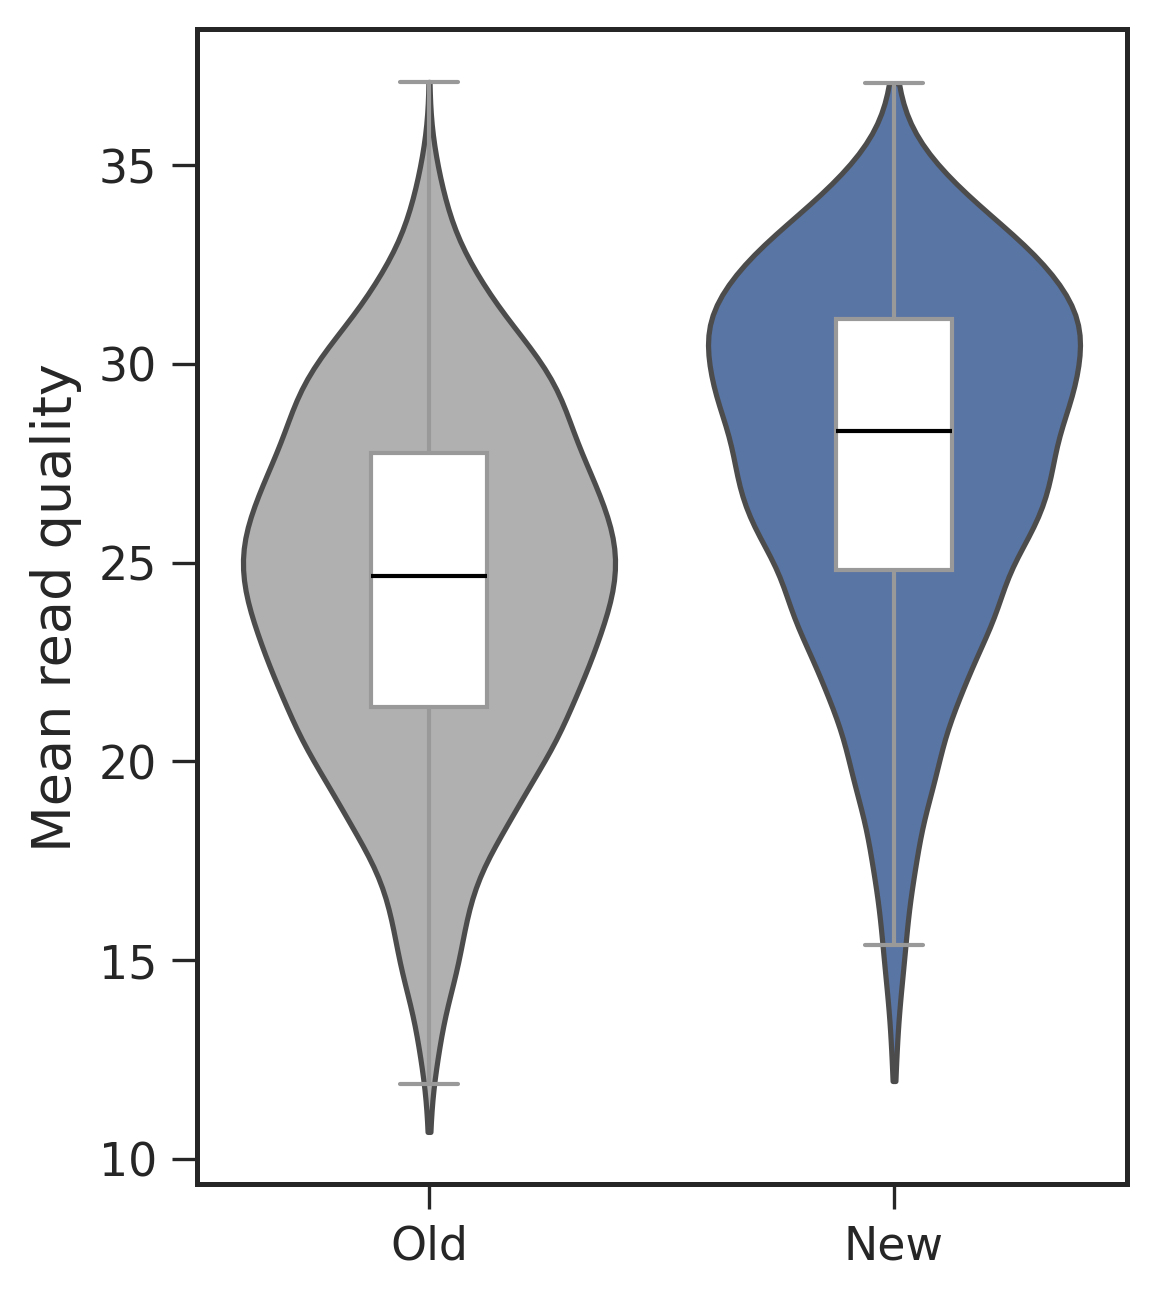

In [52]:
# ============================================
# Figure 2A
# Mean read quality
# Old vs New
# ============================================

fig, ax = make_fig(
    w=4,
    h=5,
)

sns.violinplot(
    data=read_qc,
    x="Dataset",
    y="Mean_Q",
    palette=dataset_palette,
    inner=None,
    cut=0,
    ax=ax,
)

sns.boxplot(
    data=read_qc,
    x="Dataset",
    y="Mean_Q",
    width=0.25,
    palette=["white", "white"],
    showcaps=True,
    showfliers=False,
    boxprops={"facecolor": "white", "zorder": 2},
    whiskerprops={"linewidth": 1},
    medianprops={"color": "black"},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Mean read quality")

plt.show()

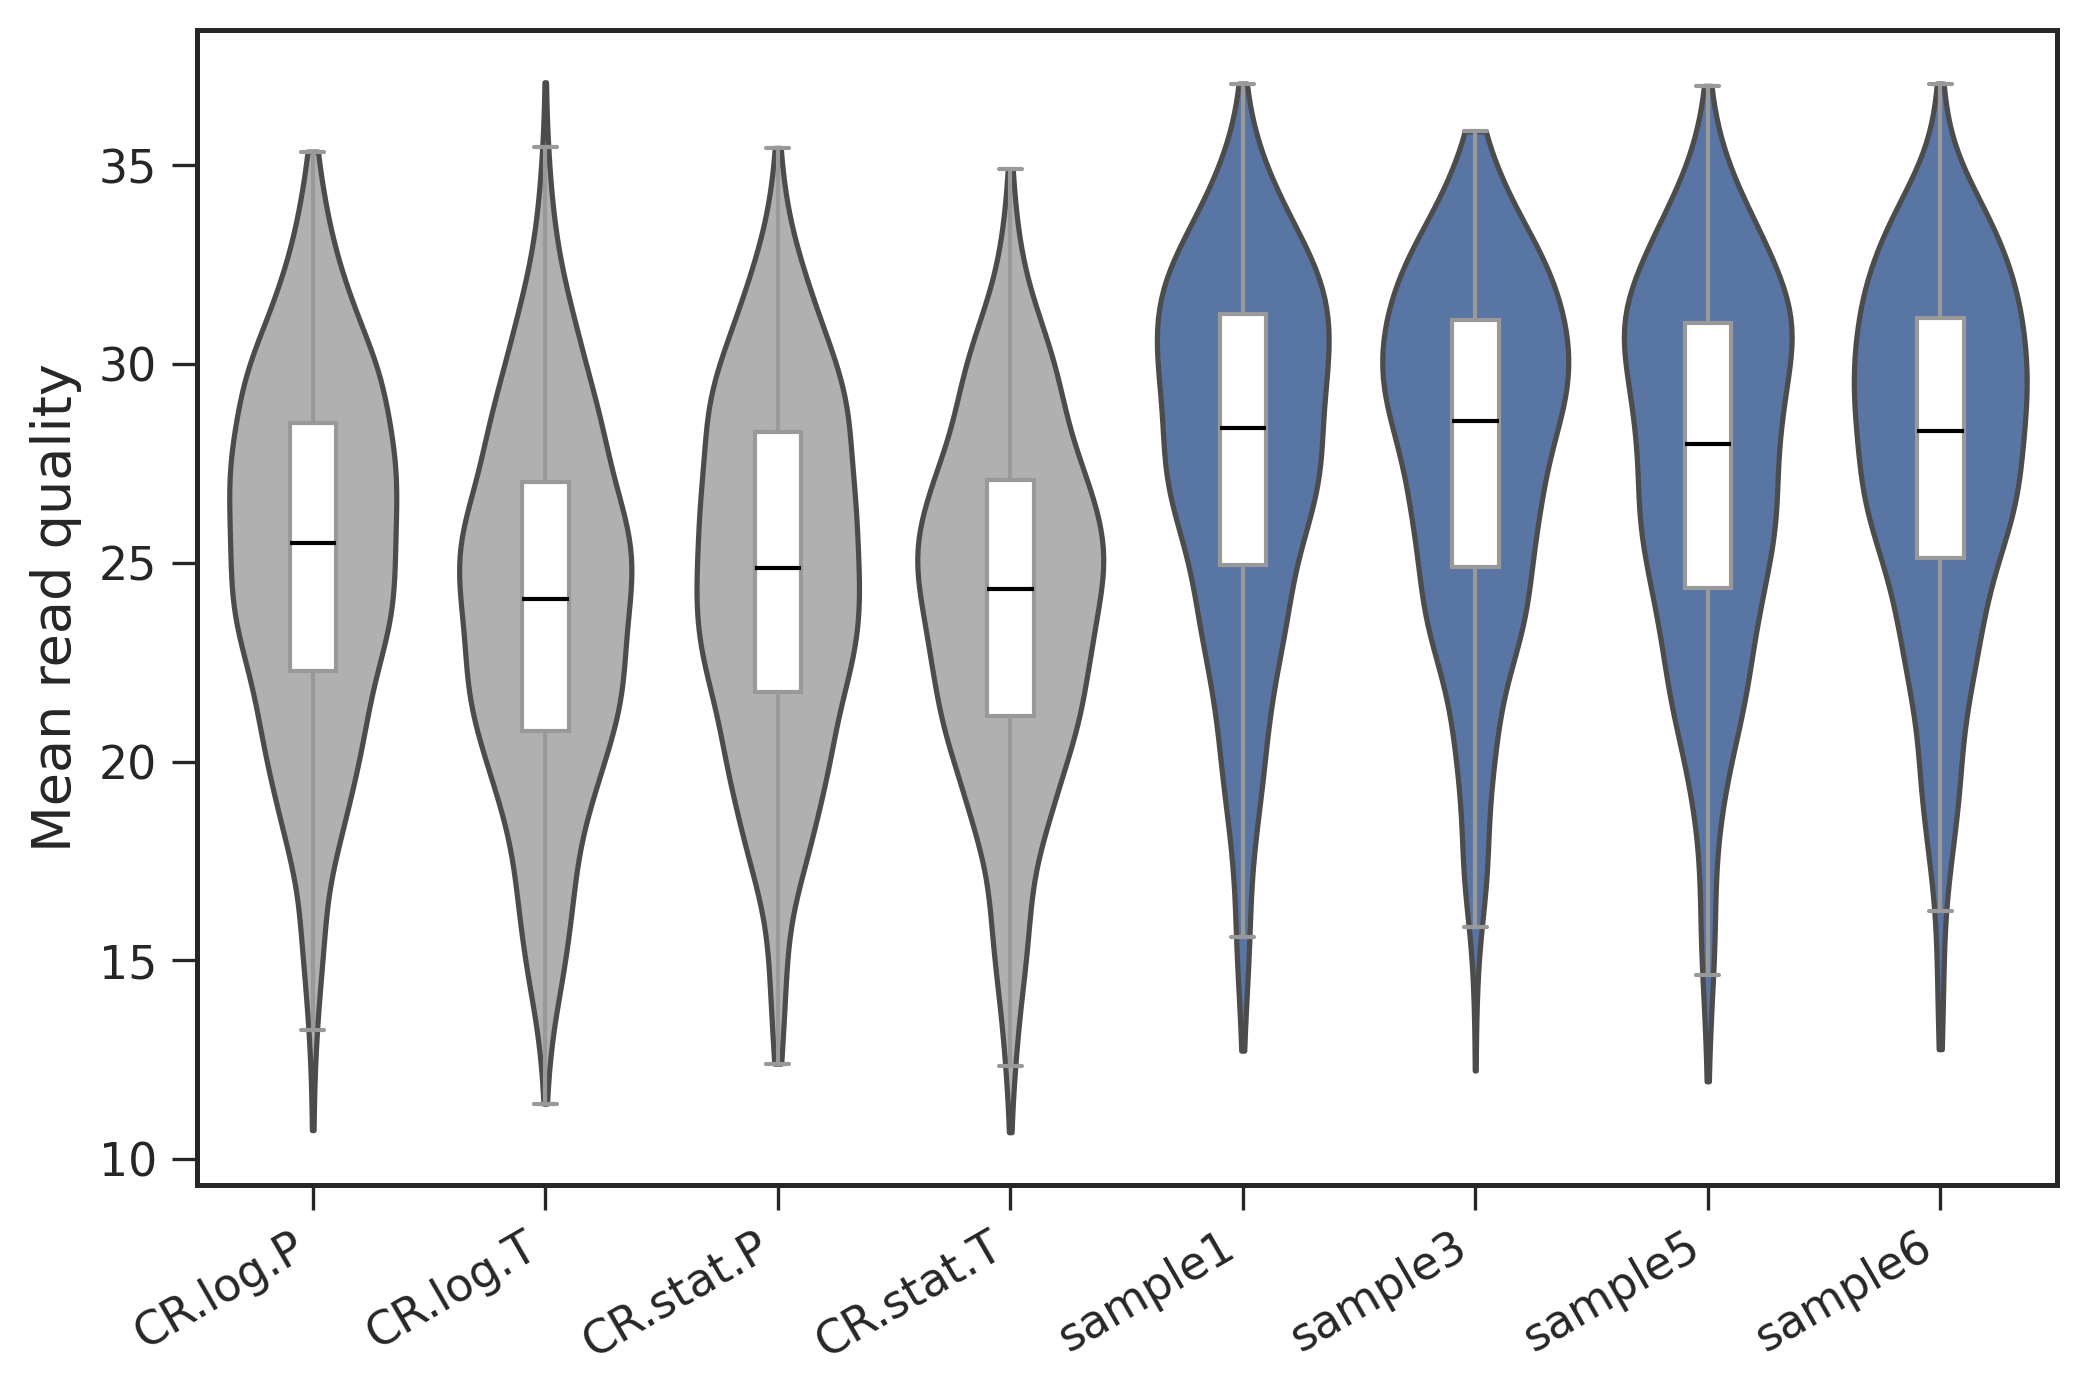

In [53]:
# ============================================
# Figure 2B
# Mean read quality
# Individual samples
# ============================================

fig, ax = make_fig(
    w=8,
    h=5,
)

sns.violinplot(
    data=read_qc,
    x="Sample",
    y="Mean_Q",
    hue="Dataset",
    order=sample_order,
    palette=dataset_palette,
    inner=None,
    cut=0,
    dodge=False,
    legend=False,
    ax=ax,
)

sns.boxplot(
    data=read_qc,
    x="Sample",
    y="Mean_Q",
    hue="Dataset",
    order=sample_order,
    palette=["white", "white"],
    dodge=False,
    width=0.20,
    showcaps=True,
    showfliers=False,
    boxprops={"facecolor": "white", "zorder": 2},
    whiskerprops={"linewidth": 1},
    medianprops={"color": "black"},
    legend=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Mean read quality")

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

plt.show()

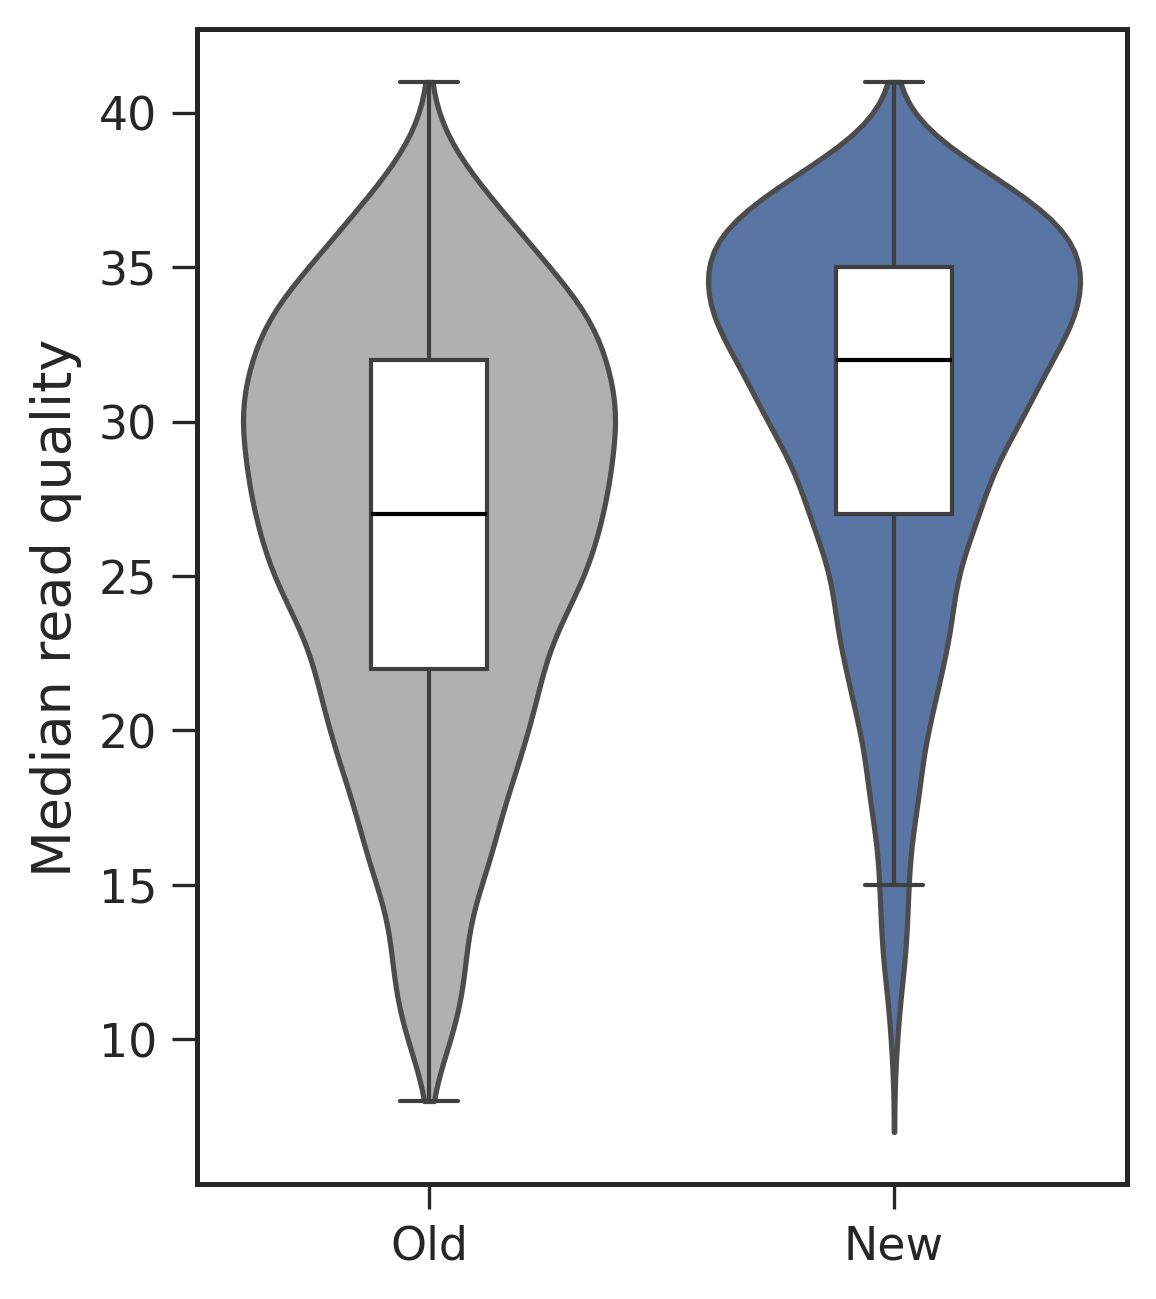

In [54]:
# ============================================
# Figure 2C
# Median read quality
# Old vs New
# ============================================

fig, ax = make_fig(w=4, h=5)

sns.violinplot(
    data=read_qc,
    x="Dataset",
    y="Median_Q",
    hue="Dataset",
    palette=dataset_palette,
    inner=None,
    cut=0,
    legend=False,
    ax=ax,
)

sns.boxplot(
    data=read_qc,
    x="Dataset",
    y="Median_Q",
    width=0.25,
    showcaps=True,
    showfliers=False,
    boxprops={"facecolor": "white", "zorder": 2},
    whiskerprops={"linewidth": 1},
    medianprops={"color": "black"},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Median read quality")

plt.show()

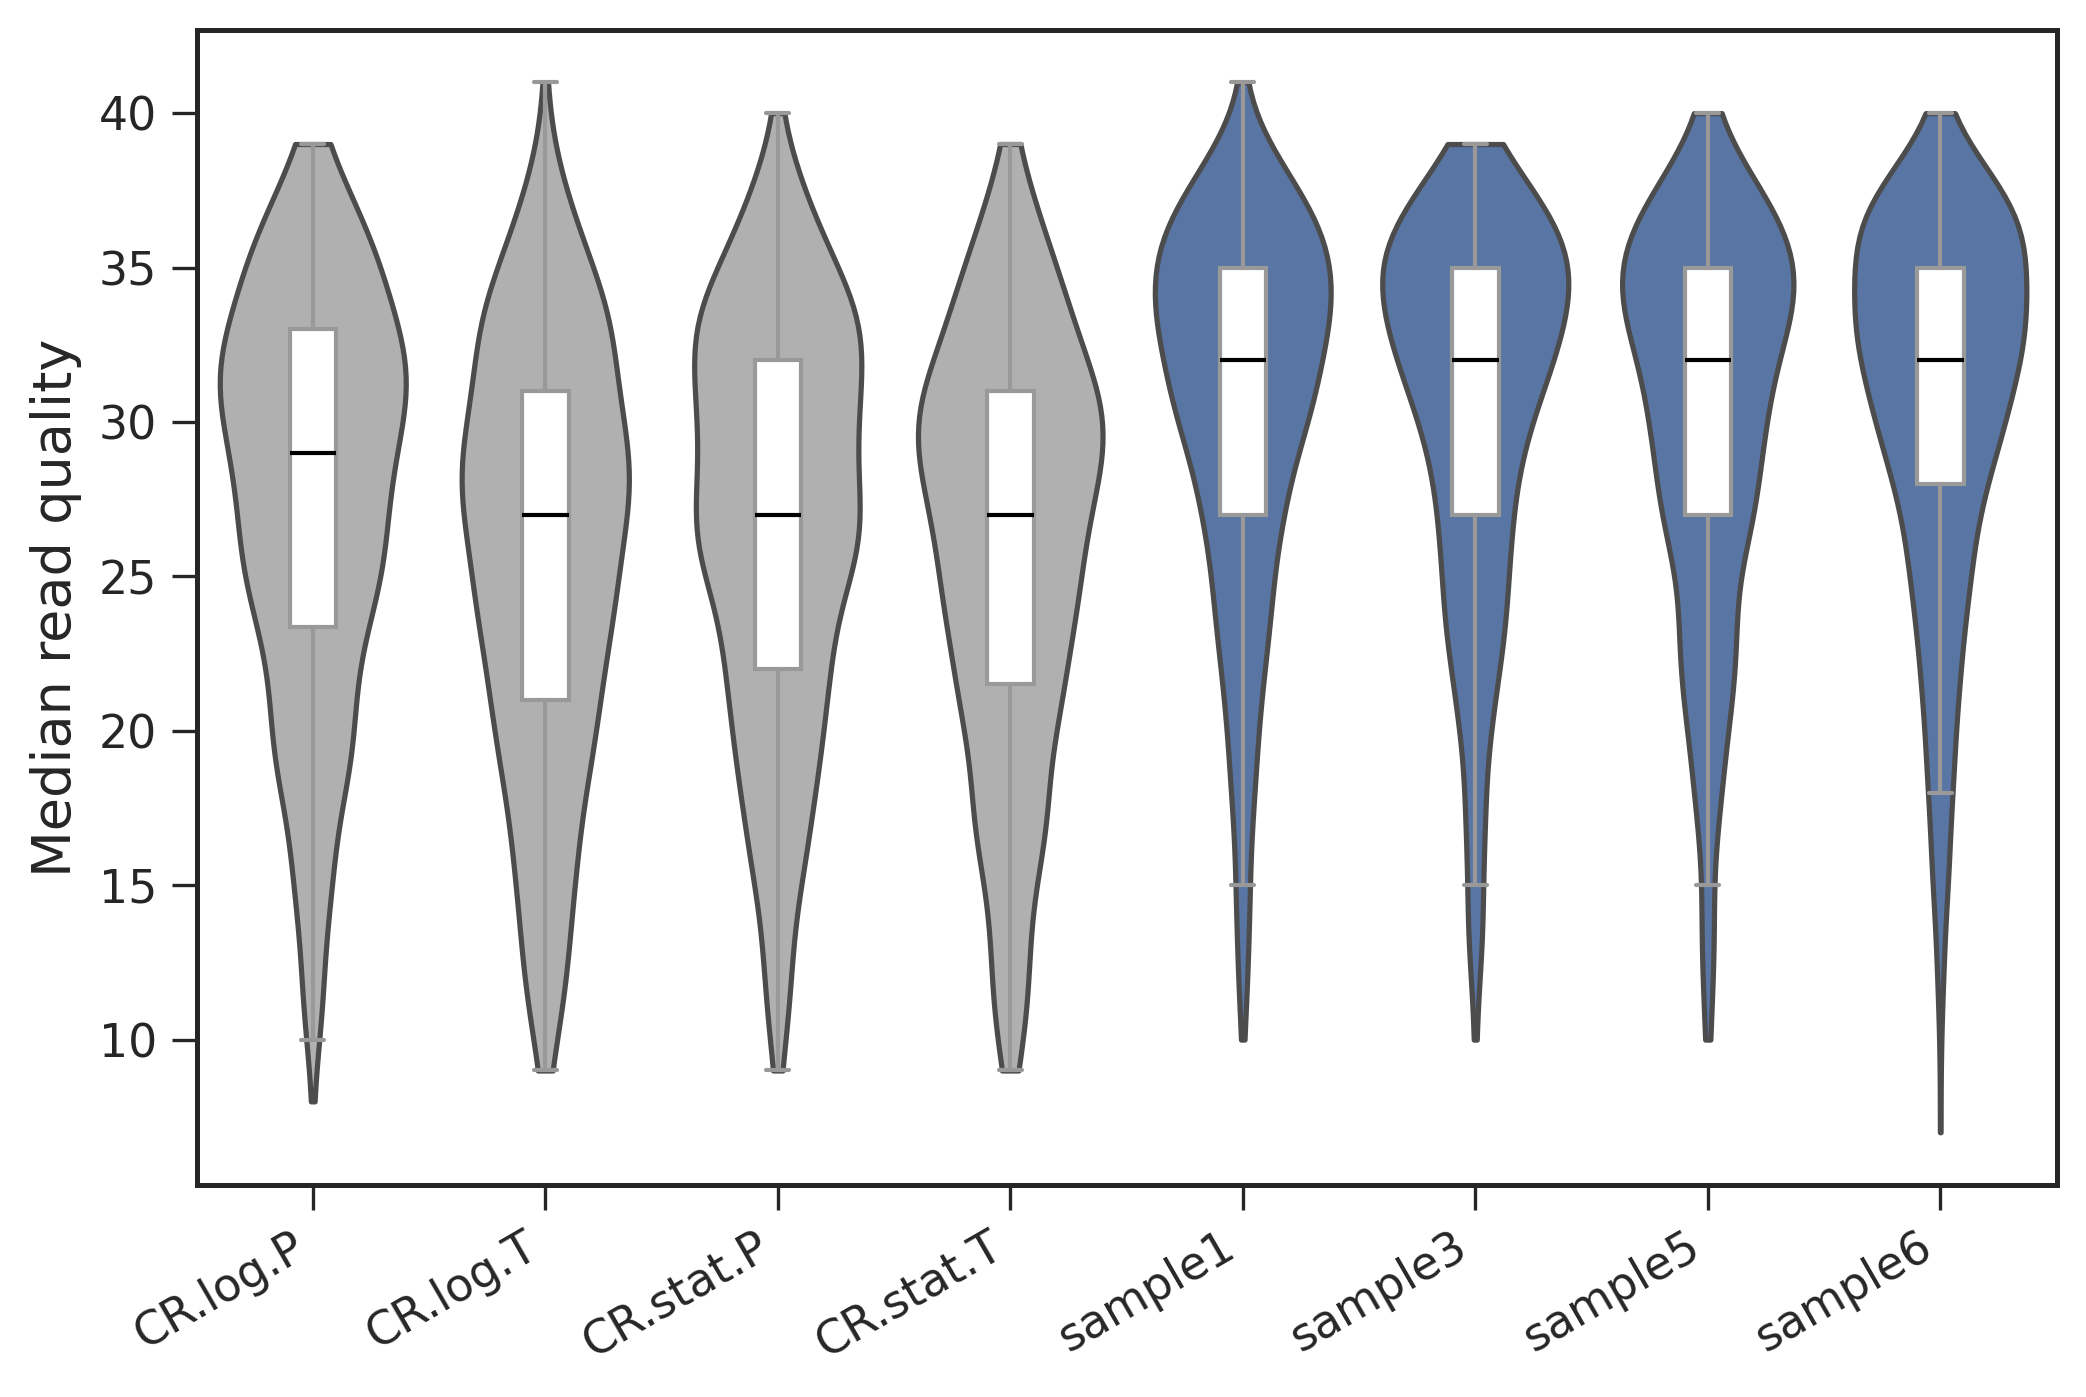

In [55]:
# ============================================
# Figure 2C
# Median read quality
# Individual samples
# ============================================

fig, ax = make_fig(
    w=8,
    h=5,
)

sns.violinplot(
    data=read_qc,
    x="Sample",
    y="Median_Q",
    hue="Dataset",
    order=sample_order,
    palette=dataset_palette,
    inner=None,
    cut=0,
    dodge=False,
    legend=False,
    ax=ax,
)

sns.boxplot(
    data=read_qc,
    x="Sample",
    y="Median_Q",
    hue="Dataset",
    order=sample_order,
    palette=["white", "white"],
    dodge=False,
    width=0.20,
    showcaps=True,
    showfliers=False,
    boxprops={"facecolor": "white", "zorder": 2},
    whiskerprops={"linewidth": 1},
    medianprops={"color": "black"},
    legend=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Median read quality")

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

plt.show()

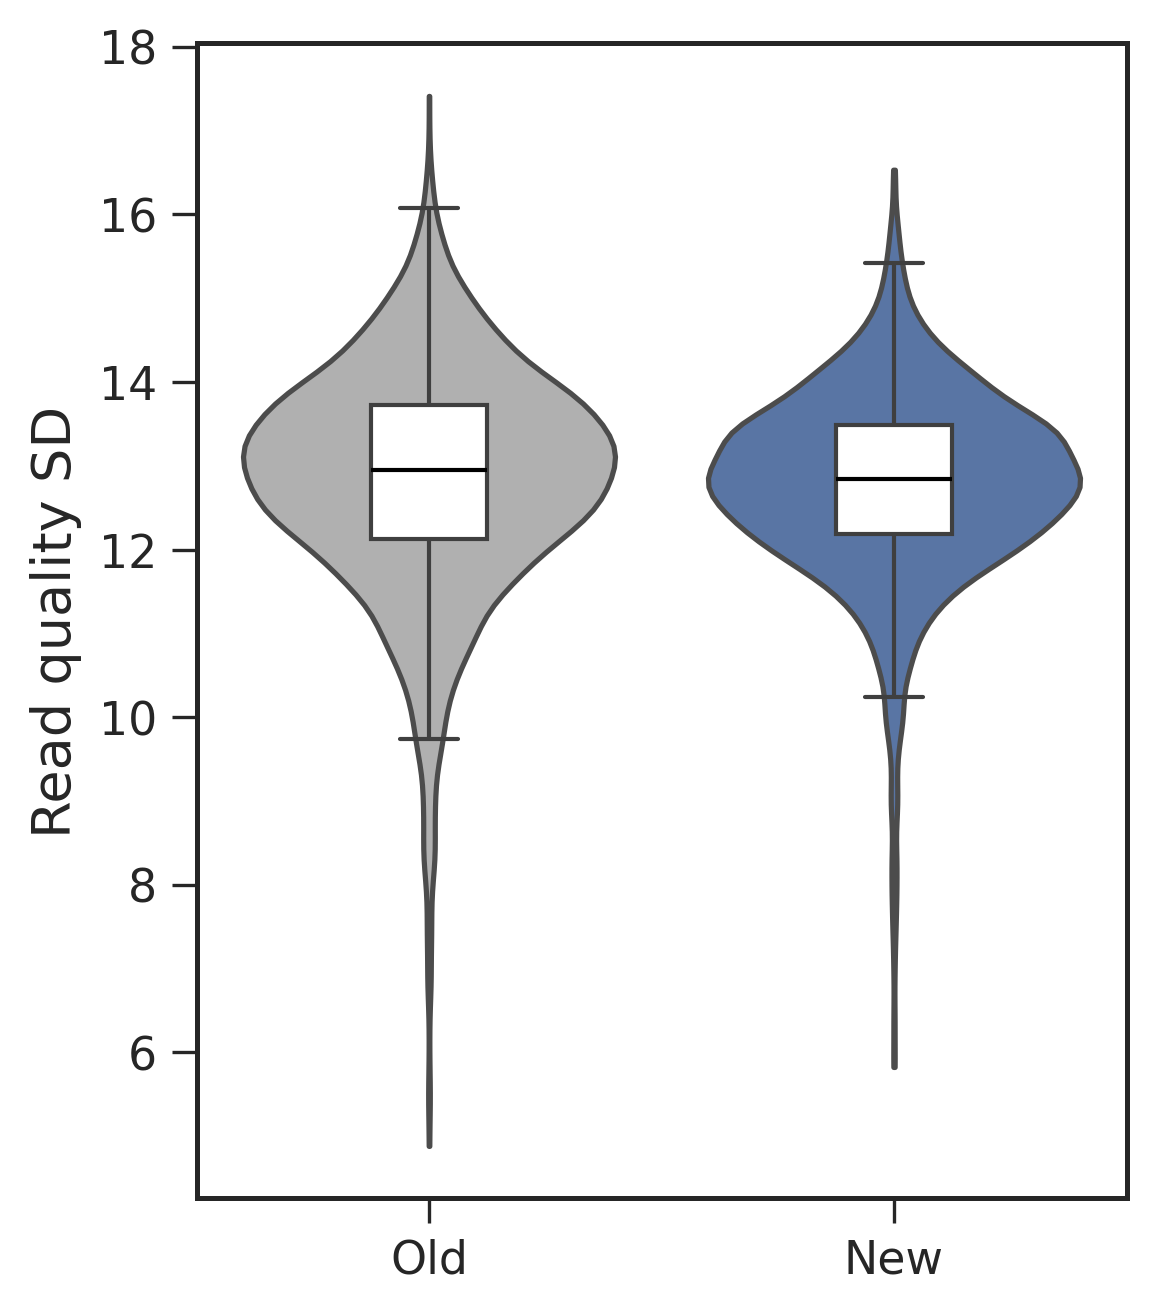

In [56]:
# ============================================
# Figure 2D
# Read quality variability
# Old vs New
# ============================================

fig, ax = make_fig(w=4, h=5)

sns.violinplot(
    data=read_qc,
    x="Dataset",
    y="Quality_SD",
    hue="Dataset",
    palette=dataset_palette,
    inner=None,
    cut=0,
    legend=False,
    ax=ax,
)

sns.boxplot(
    data=read_qc,
    x="Dataset",
    y="Quality_SD",
    width=0.25,
    showcaps=True,
    showfliers=False,
    boxprops={"facecolor": "white", "zorder": 2},
    whiskerprops={"linewidth": 1},
    medianprops={"color": "black"},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Read quality SD")

plt.show()

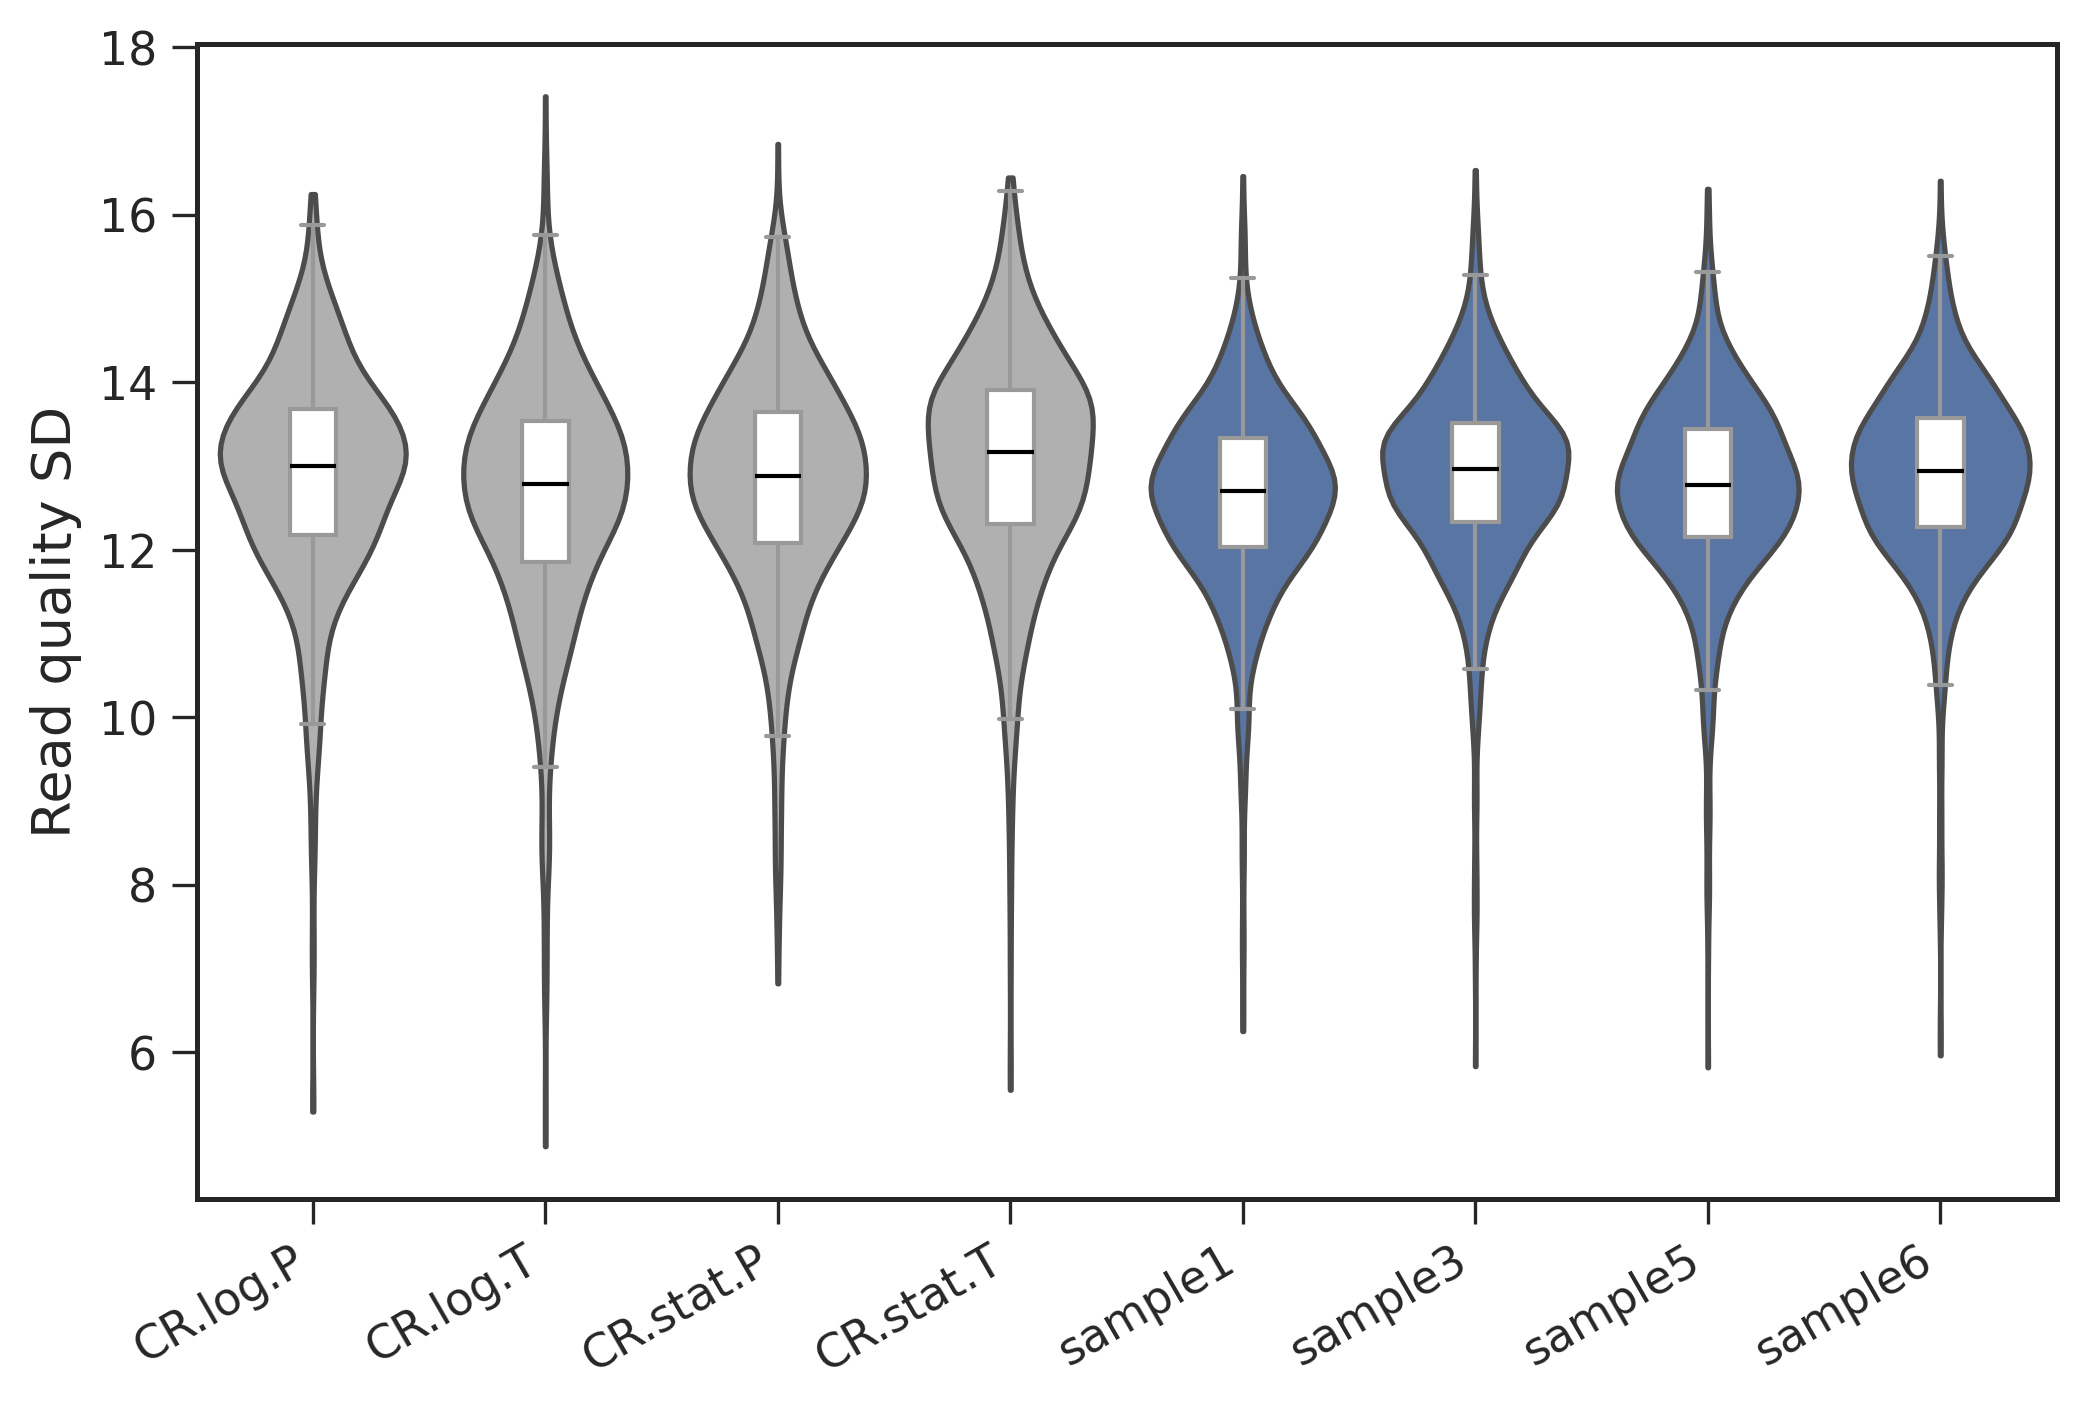

In [57]:
# ============================================
# Figure 2D
# Read quality variability
# Individual samples
# ============================================

fig, ax = make_fig(
    w=8,
    h=5,
)

sns.violinplot(
    data=read_qc,
    x="Sample",
    y="Quality_SD",
    hue="Dataset",
    order=sample_order,
    palette=dataset_palette,
    inner=None,
    cut=0,
    dodge=False,
    legend=False,
    ax=ax,
)

sns.boxplot(
    data=read_qc,
    x="Sample",
    y="Quality_SD",
    hue="Dataset",
    order=sample_order,
    palette=["white", "white"],
    dodge=False,
    width=0.20,
    showcaps=True,
    showfliers=False,
    boxprops={"facecolor": "white", "zorder": 2},
    whiskerprops={"linewidth": 1},
    medianprops={"color": "black"},
    legend=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Read quality SD")

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

plt.show()

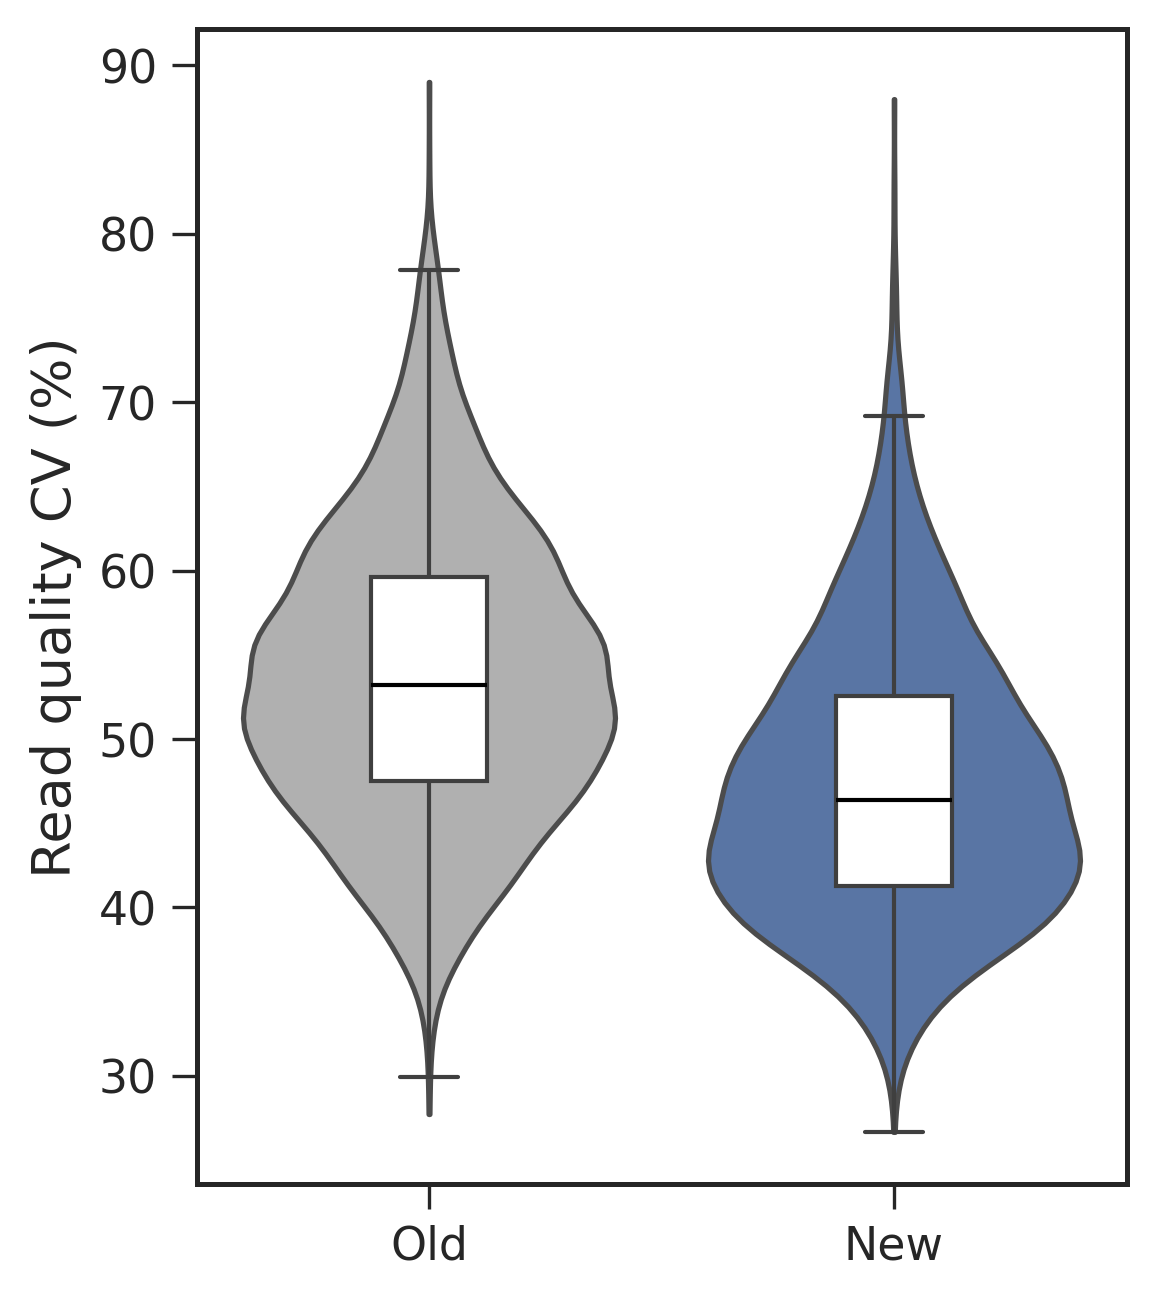

In [59]:
# ============================================
# Figure 2D
# Read quality CV
# Old vs New
# ============================================

fig, ax = make_fig(w=4, h=5)

sns.violinplot(
    data=read_qc,
    x="Dataset",
    y="Quality_CV",
    hue="Dataset",
    palette=dataset_palette,
    inner=None,
    cut=0,
    legend=False,
    ax=ax,
)

sns.boxplot(
    data=read_qc,
    x="Dataset",
    y="Quality_CV",
    width=0.25,
    showcaps=True,
    showfliers=False,
    boxprops={"facecolor": "white", "zorder": 2},
    whiskerprops={"linewidth": 1},
    medianprops={"color": "black"},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Read quality CV (%)")

plt.show()

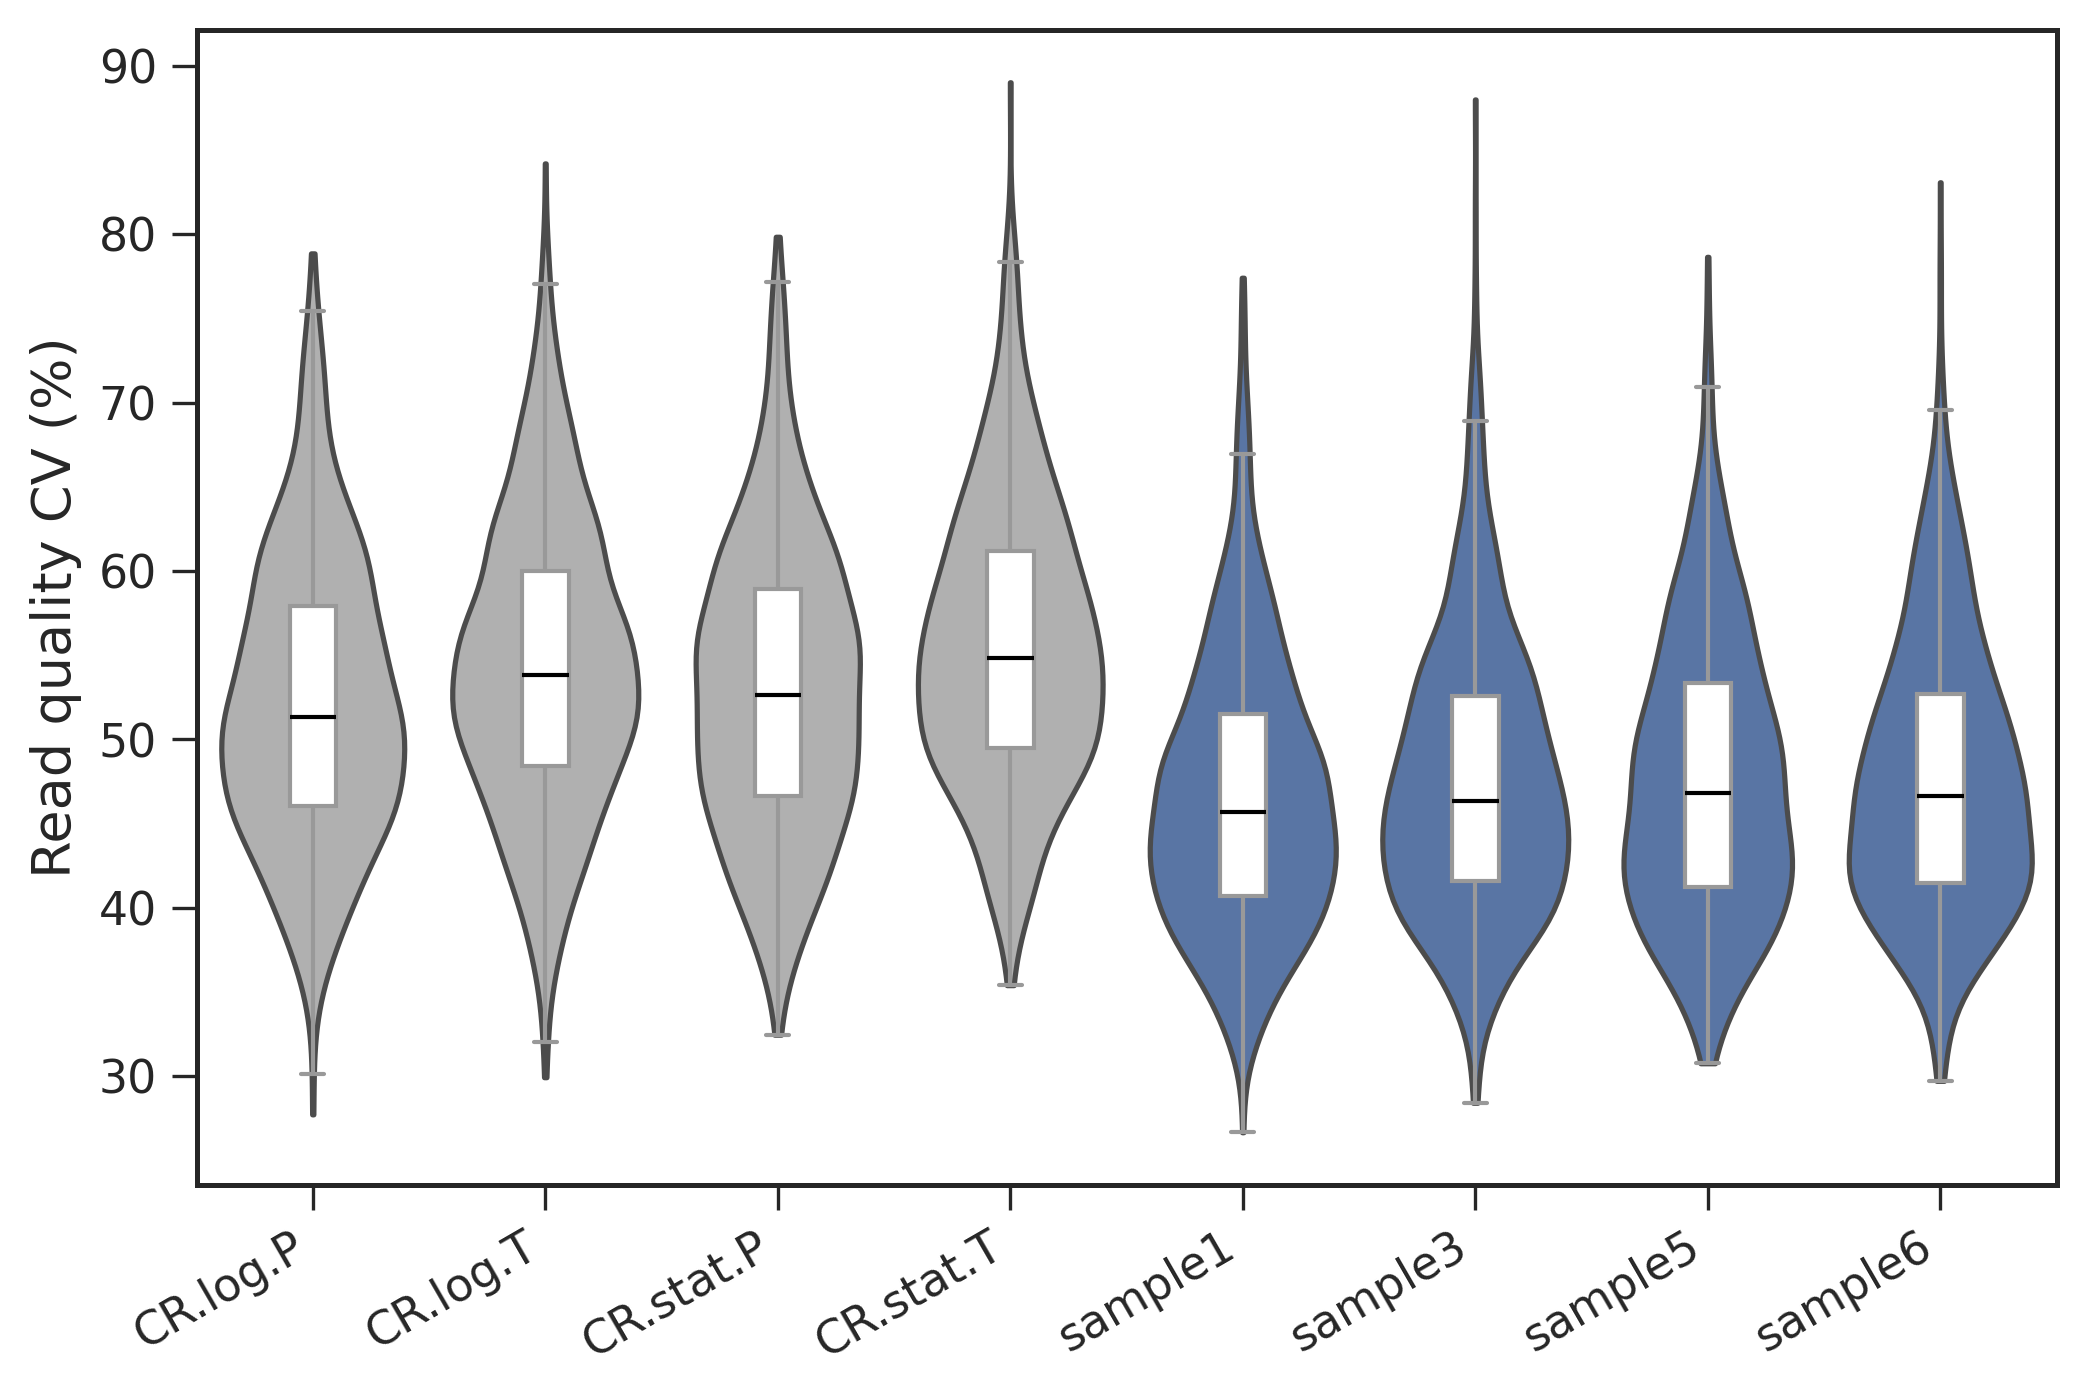

In [60]:
# ============================================
# Figure 2E
# Read quality CV
# Individual samples
# ============================================

fig, ax = make_fig(
    w=8,
    h=5,
)

sns.violinplot(
    data=read_qc,
    x="Sample",
    y="Quality_CV",
    hue="Dataset",
    order=sample_order,
    palette=dataset_palette,
    inner=None,
    cut=0,
    dodge=False,
    legend=False,
    ax=ax,
)

sns.boxplot(
    data=read_qc,
    x="Sample",
    y="Quality_CV",
    hue="Dataset",
    order=sample_order,
    palette=["white", "white"],
    dodge=False,
    width=0.20,
    showcaps=True,
    showfliers=False,
    boxprops={"facecolor": "white", "zorder": 2},
    whiskerprops={"linewidth": 1},
    medianprops={"color": "black"},
    legend=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Read quality CV (%)")

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

plt.show()

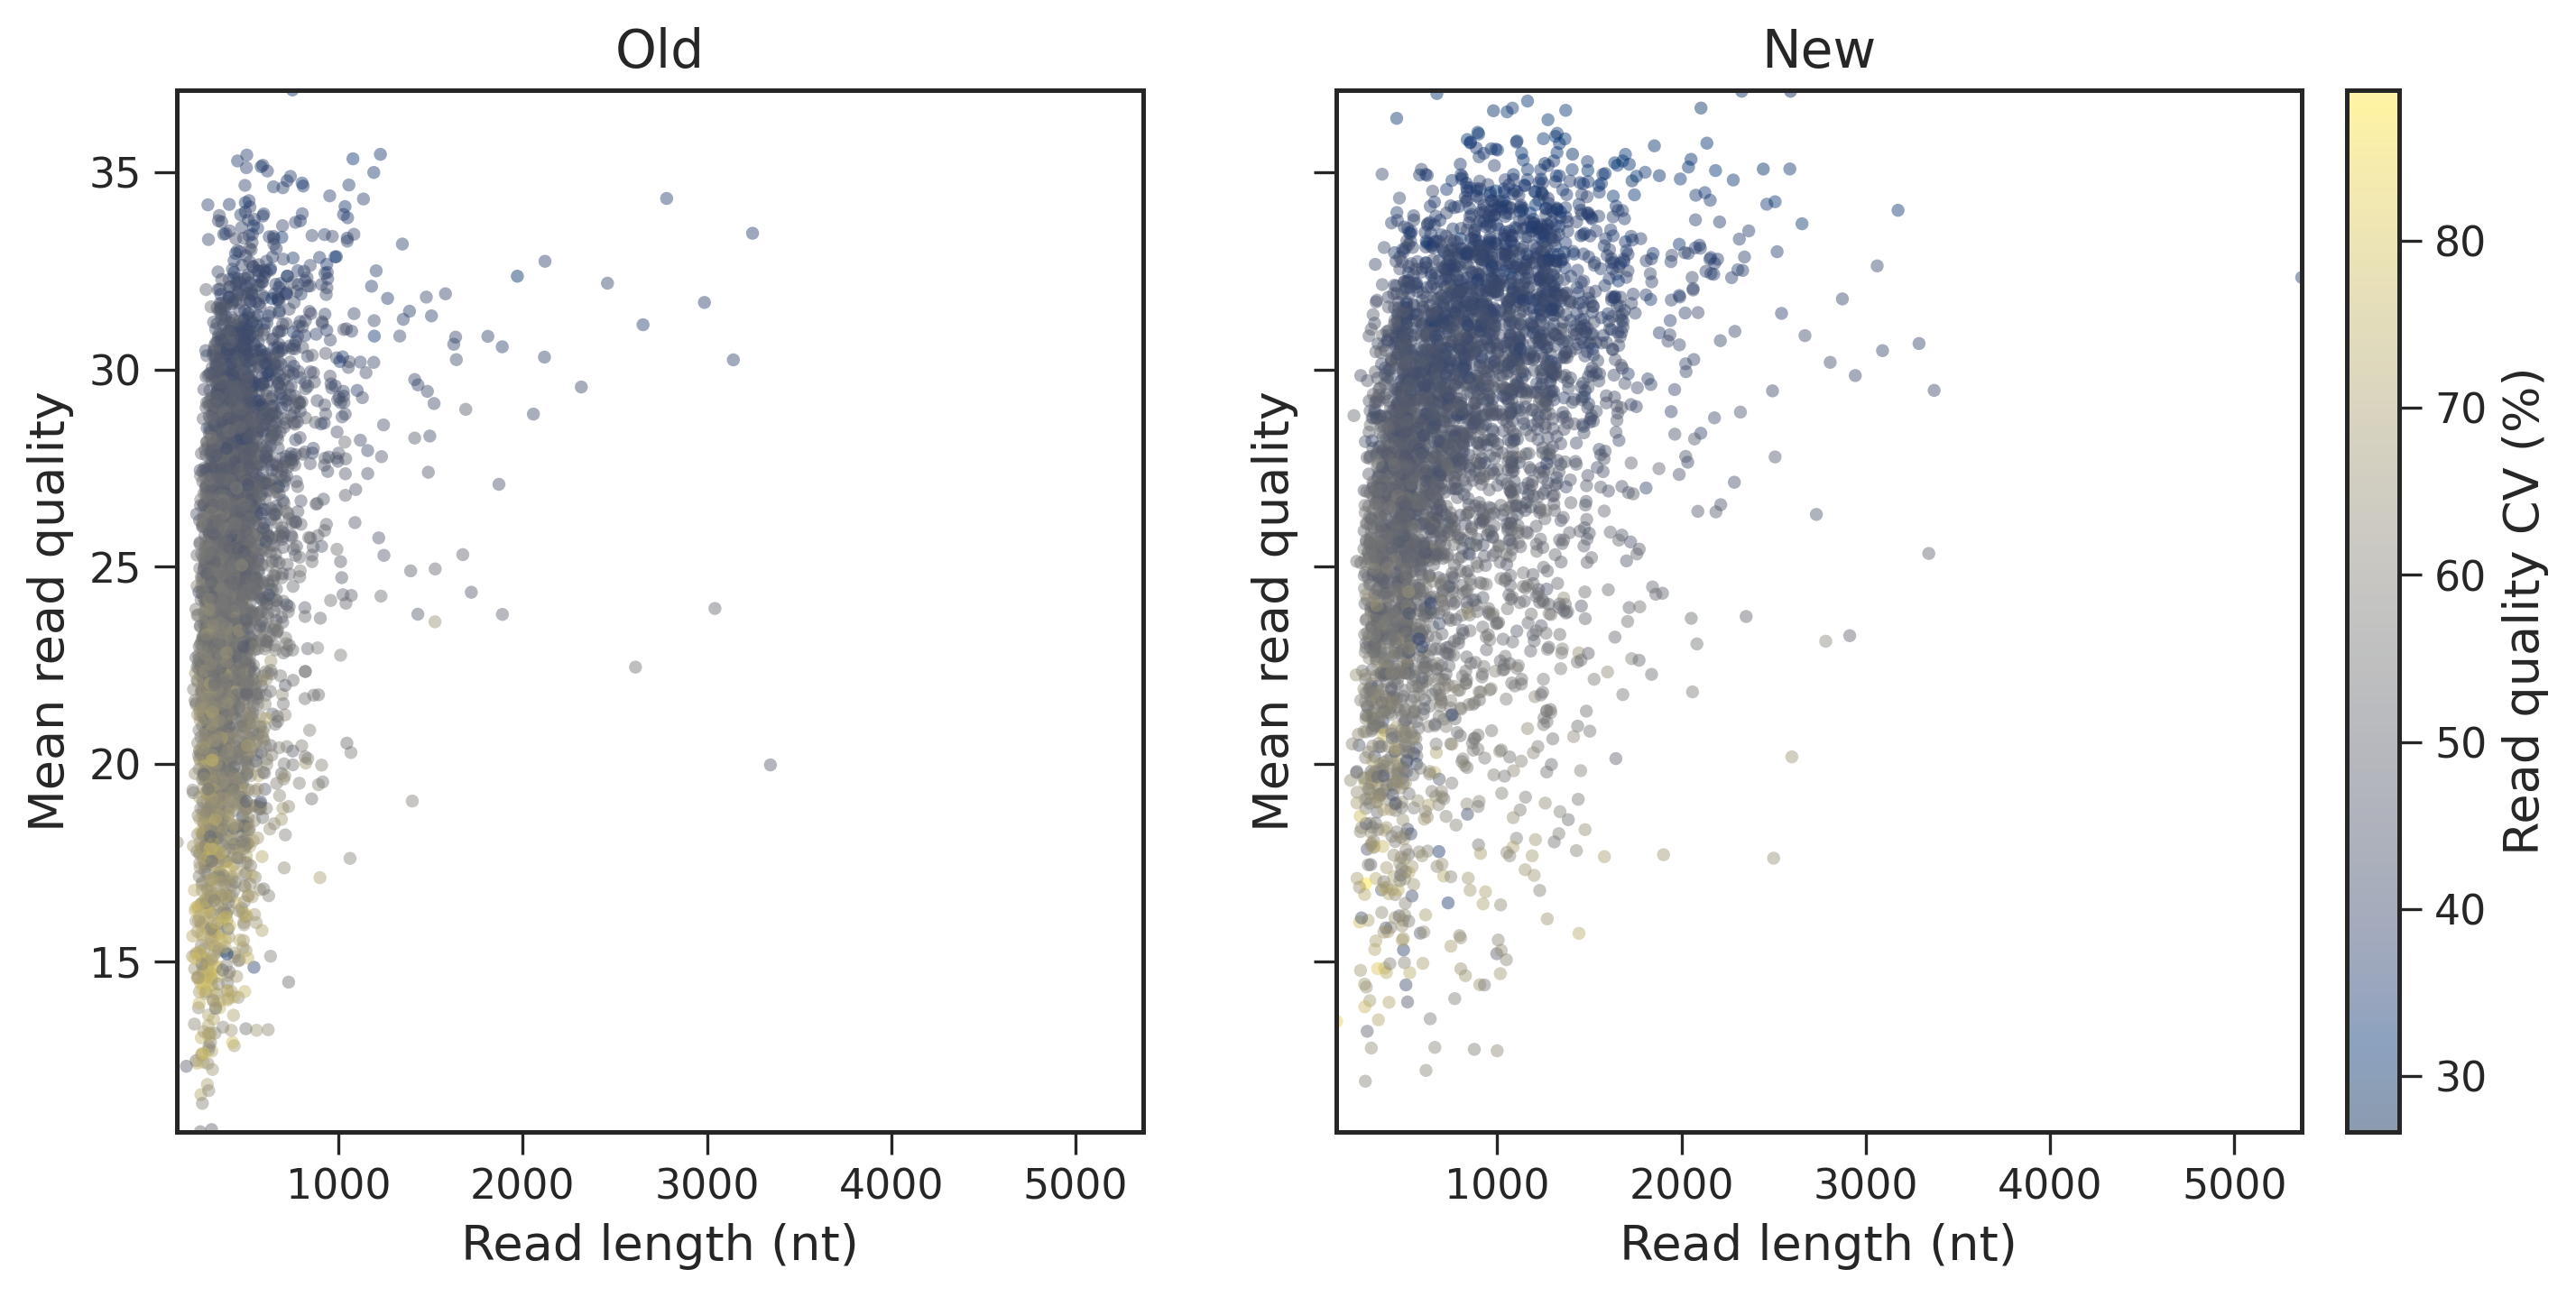

In [65]:
# ============================================
# Figure 4
# Read length vs mean quality
# Color = Read quality CV
# Old vs New
# ============================================

vmin = read_qc["Quality_CV"].min()
vmax = read_qc["Quality_CV"].max()

xmin = read_qc["Length"].min()
xmax = read_qc["Length"].max()

ymin = read_qc["Mean_Q"].min()
ymax = read_qc["Mean_Q"].max()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5),
    dpi=_PLOT_CFG["dpi"],
    sharex=True,
    sharey=True,
)

for ax, dataset in zip(axes, ["Old", "New"]):

    data_sub = read_qc[
        read_qc["Dataset"] == dataset
    ]

    sc = ax.scatter(
        data_sub["Length"],
        data_sub["Mean_Q"],
        c=data_sub["Quality_CV"],
        cmap="cividis",
        vmin=vmin,
        vmax=vmax,
        s=12,
        alpha=0.45,
        linewidth=0,
        rasterized=True,
    )

    ax.set_title(dataset)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_xlabel("Read length (nt)")
    ax.set_ylabel("Mean read quality")

# Leave space for colorbar
fig.subplots_adjust(right=0.88)

# Colorbar outside both panels
cbar = fig.colorbar(
    sc,
    ax=axes,
    location="right",
    fraction=0.035,
    pad=0.02,
)

cbar.set_label("Read quality CV (%)")

plt.show()